In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Đọc file CSV 
df = pd.read_csv('D:/startup-funding-analysis/data/investments_VC.csv', encoding='latin-1')

#Xem 5 dòng đầu tiên
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Xem có bao nhiêu dòng và bao nhiêu cột
print("Số dòng và cột:", df.shape)

# Xem tên các cột
print("\nCác cột:", df.columns.tolist())

# Xem kiểu dữ liệu
print("\nKiểu dữ liệu:")
print(df.dtypes)

Số dòng và cột: (54294, 39)

Các cột: ['permalink', 'name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

Kiểu dữ liệu:
permalink                object
name                     object
homepage_url             object
category_list            object
 market                  object
 funding_total_usd       object
status                   object
country_code             object
state_code               object
region                   object
city                     object
funding_rounds          f

In [5]:
# Xem cột nào bị thiếu dữ liệu
missing = df.isnull().sum()
print("Dữ liệu bị thiếu:\n", missing[missing > 0])

Dữ liệu bị thiếu:
 permalink                4856
name                     4857
homepage_url             8305
category_list            8817
 market                  8824
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15812
first_funding_at         4856
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B              

In [6]:
# Xóa dấu cách thừa ở tất cả tên cột
df.columns = df.columns.str.strip()

# Kiểm tra lại tên cột
print(df.columns.tolist())

['permalink', 'name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'founded_month', 'founded_quarter', 'founded_year', 'first_funding_at', 'last_funding_at', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding', 'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']


In [7]:
# Xóa các dòng không có thông tin quan trọng
df_clean = df.dropna(subset=['market', 'country_code', 'funding_total_usd'])

# Reset lại index
df_clean = df_clean.reset_index(drop=True)

print("Số dòng sau khi làm sạch", len(df_clean))

Số dòng sau khi làm sạch 41329


In [8]:
# Kiểm tra kiểu dữ liệu cột funding_total_usd
print(df_clean['funding_total_usd'].dtype)
print(df_clean['funding_total_usd'].head(10))

object
0     17,50,000 
1     40,00,000 
2        40,000 
3     15,00,000 
4        60,000 
5     70,00,000 
6     49,12,393 
7           -   
8        41,250 
9        40,000 
Name: funding_total_usd, dtype: object


In [9]:
# Chuyển cột funding_total_usd từ text sang số
df_clean['funding_total_usd'] = pd.to_numeric(
    df_clean['funding_total_usd'], 
    errors='coerce'  
)

# Xóa các dòng vừa thành NaN sau khi chuyển
df_clean = df_clean.dropna(subset=['funding_total_usd'])

# Kiểm tra lại
print("Kiểu dữ liệu sau khi fix:", df_clean['funding_total_usd'].dtype)
print("Số dòng còn lại:", len(df_clean))

Kiểu dữ liệu sau khi fix: float64
Số dòng còn lại: 28


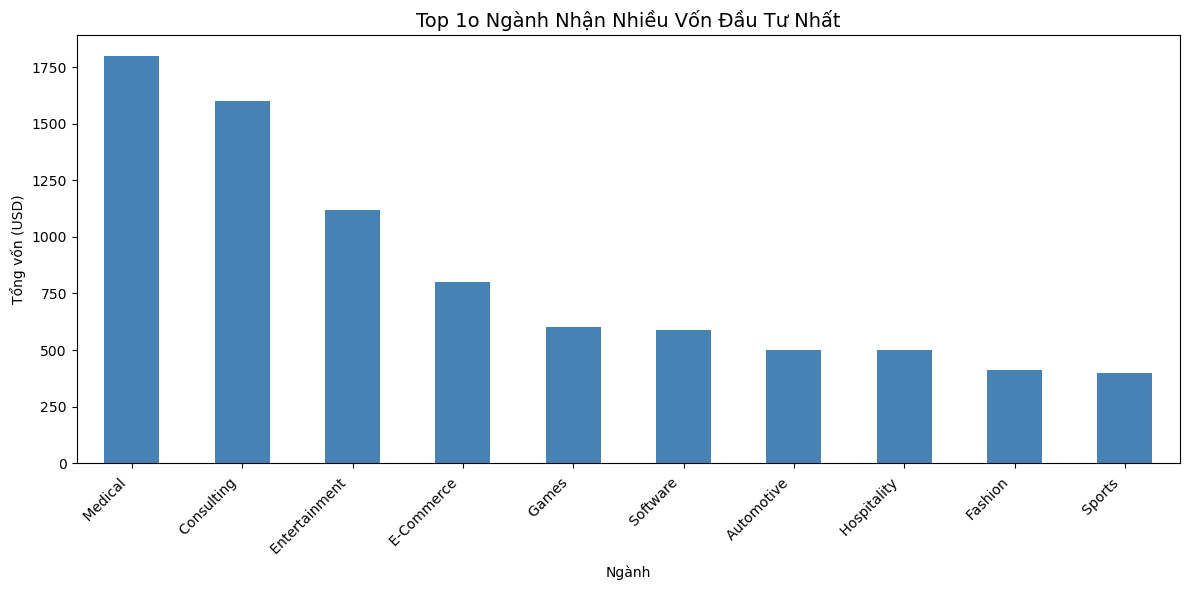

In [10]:
# Câu hỏi 1: Ngành nào nhận nhiều vốn nhất?
# Top 10 ngành nhận nhiều vốn nhất
top_markets = df_clean.groupby('market')['funding_total_usd'].sum()
top_markets = top_markets.sort_values(ascending=False).head(10)
                               
# Chia cho 1 tỷ trước khi vẽ
top_markets_billion = top_markets / 1_000_000_000

# Vẽ biểu đồ cột
plt.figure(figsize=(12,6))
top_markets.plot(kind='bar', color='steelblue')
plt.title('Top 1o Ngành Nhận Nhiều Vốn Đầu Tư Nhất', fontsize=14)
plt.xlabel('Ngành')
plt.ylabel('Tổng vốn (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('D:/startup-funding-analysis/data/bieu_do_1.png')
plt.show()

# Nhận xét biểu đồ 1:
# 1. Medical dẫn đầu về tổng số vốn đầu tư (~1800 tỷ USD), theo sau là Consulting (~1600 tỷ USD) và Entertainment (~1100 tỷ USD)

# 2. Top 3 ngành (Medical, Consulting, Entertainment) nhận vốn cao hơn hẳn so với 7 ngành còn lại

# 3. Các ngành như fashion và Sports nhận vốn ít nhất, chỉ khoảng ~400 tỷ USD - thấp hơn 4 lần so với Medical

# Đề xuất: Nhà đầu tư muốn tối đa hóa lợi nhuận nên ưu tiên rót vốn vào ngành Medical và Consulting vì đây là 2 ngành thu hút vốn lớn nhất, cho thấy được tiềm năng tăng trưởng của 2 ngành ny là cao nhất


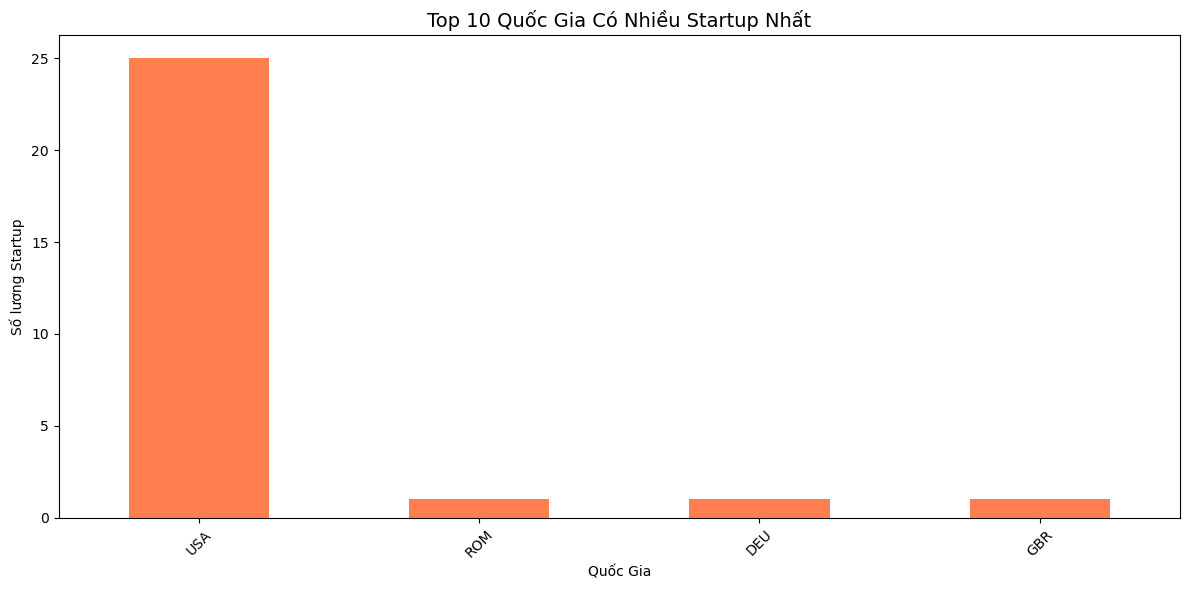

In [11]:
# Câu hỏi 2: Quốc gia nào có nhiều startup nhất?
# Top 10 quốc gia có nhiều startup nhất
top_countries = df_clean['country_code'].value_counts().head(10)

# Vẽ biểu đồ
plt.figure(figsize=(12,6))
top_countries.plot(kind='bar', color='coral')
plt.title('Top 10 Quốc Gia Có Nhiều Startup Nhất', fontsize=14)
plt.xlabel('Quốc Gia')
plt.ylabel('Số lương Startup')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('D:/startup-funding-analysis/data/bieu_do_2.png')
plt.show()

# Nhận xét biểu đồ 2:
# 1. Quốc gia có nhiều startup nhất là USA với số lượng áp đảo
# 2. Các quốc gia còn lại là Romania, Đức và Vương Quốc Anh có số lượng startup gần như tương đương nhau

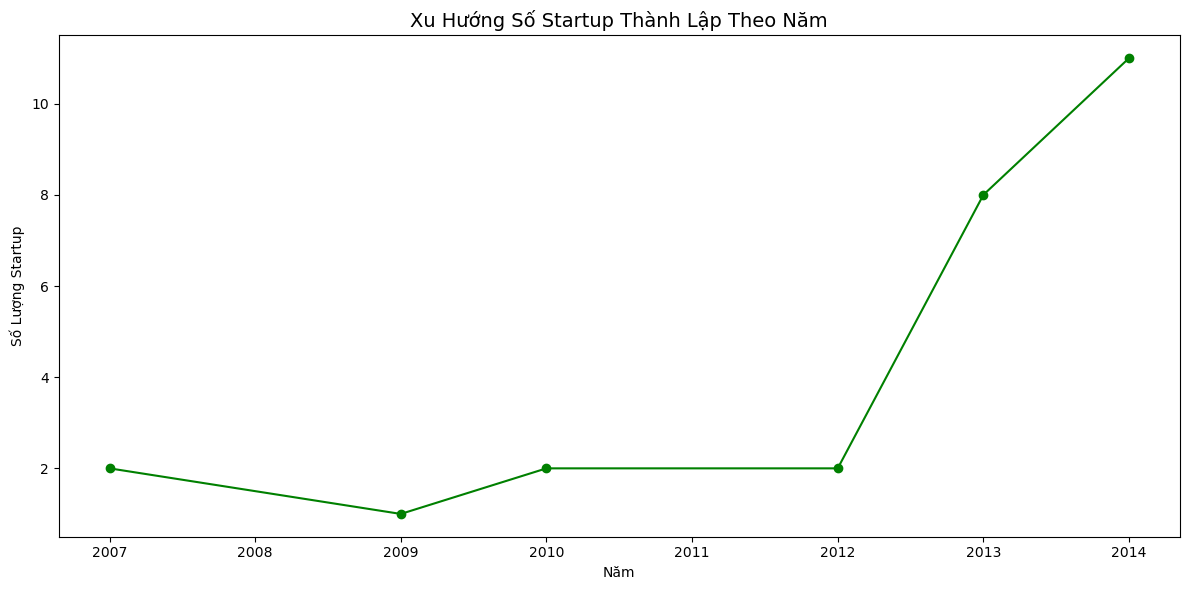

In [12]:
# Xu hướng đầu tư theo năm
# Chuyển cột năm thành số
df_clean['founded_year'] = pd.to_numeric(df_clean['founded_year'], errors='coerce')

# Lọc năm hợp lệ (2000-2015)
df_year = df_clean[
    (df_clean['founded_year'] >= 2000) & 
    (df_clean['founded_year'] <= 2015)
]

# Đếm số startup theo năm
startup_per_year = df_year.groupby('founded_year').size()

plt.figure(figsize=(12, 6))
startup_per_year.plot(kind='line', marker='o', color='green')
plt.title('Xu Hướng Số Startup Thành Lập Theo Năm', fontsize=14)
plt.xlabel('Năm')
plt.ylabel('Số Lượng Startup')
plt.tight_layout()
plt.savefig('D:/startup-funding-analysis/data/bieu_do_3.png')
plt.show()

# Nhận xét:
# 1. Năm 2014 có số lượng startup nhiều nhất

# 2. Số lượng startup bắt đầu tăng đáng kể là từ năm 2012, sau đó đến năm 2013 và cuối cùng là năm 2014

# 3. Năm 2009 có số lượng startup thấp nhất trong tất cả các năm

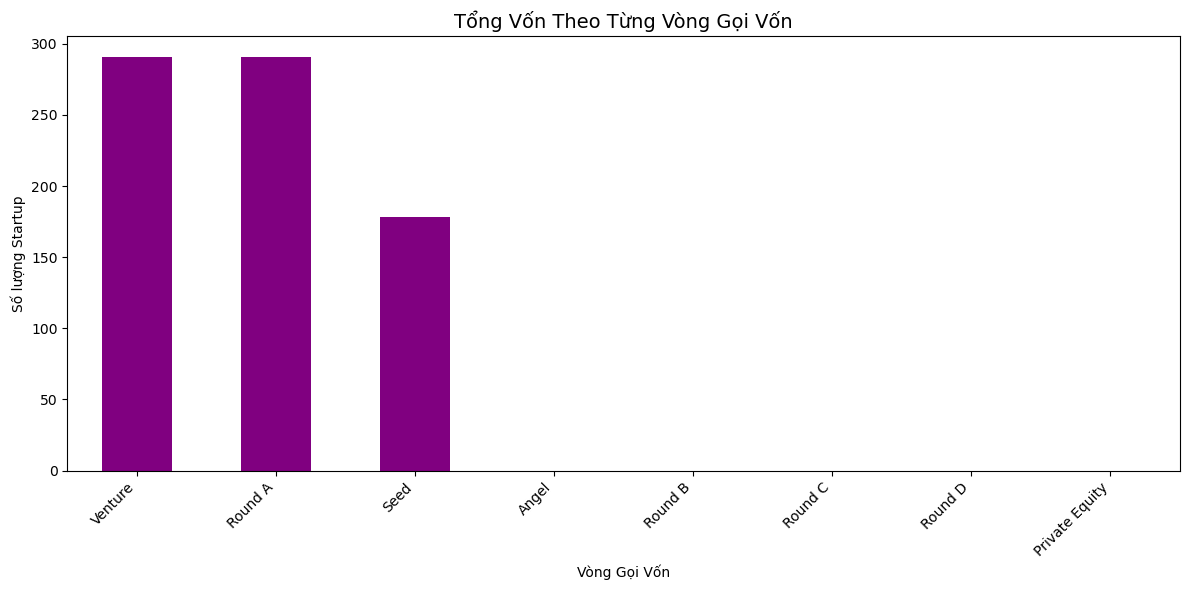

In [15]:
# Câu hỏi 4: Vòng gọi vốn nào phổ biến nhất?
# Tính tổng từng vòng gọi vốn
rounds = {
    'Seed'          : df_clean['seed'].sum(),
    'Venture'       : df_clean['venture'].sum(),
    'Angel'         : df_clean['angel'].sum(),
    'Round A'       : df_clean['round_A'].sum(),
    'Round B'       : df_clean['round_B'].sum(),
    'Round C'       : df_clean['round_C'].sum(),
    'Round D'       : df_clean['round_D'].sum(),
    'Private Equity': df_clean['private_equity'].sum(),
}

# Chuyển thành Series và sắp xếp
rounds_series = pd.Series(rounds).sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
rounds_series.plot(kind='bar', color='purple')
plt.title('Tổng Vốn Theo Từng Vòng Gọi Vốn', fontsize=14)
plt.xlabel('Vòng Gọi Vốn')
plt.ylabel('Số lượng Startup')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('D:/startup-funding-analysis/data/bieu_do_4.png')
plt.show()

# Nhận xét:
# 1. Venture Capital và Round A là 2 vòng gọi vốn phổ biến nhất với tổng số vốn ~290 startup mỗi loại - cho thấy đây là 2 hình thức gọi vốn được startup lựa chọn nhiều nhất
# 2. Seed funding đứng thứ 3 với ~175 startup - đây là vòng vố khởi đầu cho startup ở giai đoạn rất sớm
# 3. Round B, C, D gần như bằng 0 - cho thấy rất ít startup tồn tại được đến giai đoạn tăng trưởng muộn


# Kết luận

1. NGÀNH HOT NHẤT: Medical và Consulting, chiếm ưu thế rõ rệt, chiếm tổng cộng gần 41% trong top 10 ngành được nhận nhiều vốn nhất 


2. QUỐC GIA DẪN ĐẦU VỀ SỐ LƯỢNG STARTUP: USA với sự thống trị tuyệt đối với 25 startup, chiếm gần 90% tổng số startup cho thấy sự tập trung cực kì lớn vào thị trường Mỹ

3. XU HƯỚNG ĐẦU TƯ THEO NĂM: Startup tăng mạnh từ năm 2012-2014, đỉnh điểm là ở năm 2014

4. VÒNG GỌI VỐN PHỔ BIẾN NHẤT: Venture và Round A, cuối cùng là Seed

5. ĐỀ XUẤT:
* Nhà đầu tư: Xây dựng danh mục tập trung vào ngành Medical/Consulting ở giai đoạn Seed–Round A, đa dạng hóa địa lý sang châu Âu để giảm rủi ro và theo dõi chu kỳ công nghệ để vào vốn đúng thời điểm
* Startup:  Chọn ngành có dòng vốn lớn, ra mắt sớm trong chu kỳ tăng trưởng, tập trung tìm product-market fit trước khi gọi vốn lớn và nếu ở ngoài Mỹ thì chủ động tiếp cận hệ sinh thái quốc tế